In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Unit_Price,Revenue,Cost,Profit
0,1,2023-10-08,1154,Mouse,Accessories,East,3,578.87,1736.61,881.05,855.56
1,2,2023-11-10,1034,Monitor,Electronics,North,5,1202.30,6011.50,3846.37,2165.13
2,3,2023-11-27,1118,Tablet,Electronics,North,1,1325.29,1325.29,827.90,497.39
3,4,2023-06-16,1080,Phone,Electronics,South,2,583.26,1166.52,808.85,357.67
4,5,2023-10-04,1110,Laptop,Electronics,East,5,1029.39,5146.95,2839.39,2307.56


In [6]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

## Basic Analysis


In [8]:
#Total re
df['Revenue'].sum()

np.float64(3494442.12)

In [9]:
#Total profit
df['Profit'].sum()

np.float64(1218379.3)

### Sales by Category

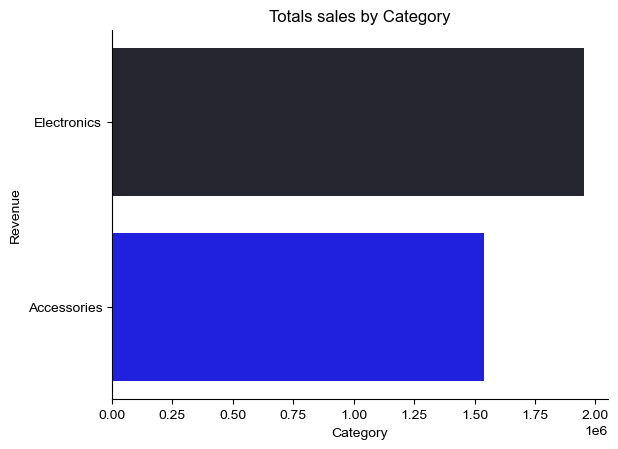

In [10]:
df_cat = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
sns.barplot(data=df_cat.reset_index(), x='Revenue', y='Category', hue='Category', dodge=False, palette='dark:b')
sns.set_theme(style='ticks')
sns.despine()

#df_cat.plot(kind='bar')
plt.title('Totals sales by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

In [11]:
df.groupby('Category')[['Revenue', 'Profit']].sum()

,Revenue,Profit
Category,,
Accessories,1540525.18,540766.42
Electronics,1953916.94,677612.88


## Monthly Sales Trend

In [12]:
df['month'] = df['Order_Date'].dt.to_period('M')

In [13]:
monthly_rates = df.groupby('month')['Revenue'].sum().sort_values(ascending=False)
monthly_rates

month
2023-03    372868.11
2023-05    328038.22
2023-06    310131.35
2023-09    294844.73
2023-02    294489.37
2023-08    286063.81
2023-10    283715.06
2023-04    278988.41
2023-12    269197.96
2023-01    268704.50
2023-11    267177.93
2023-07    237741.03
2024-01      2481.64
Freq: M, Name: Revenue, dtype: float64

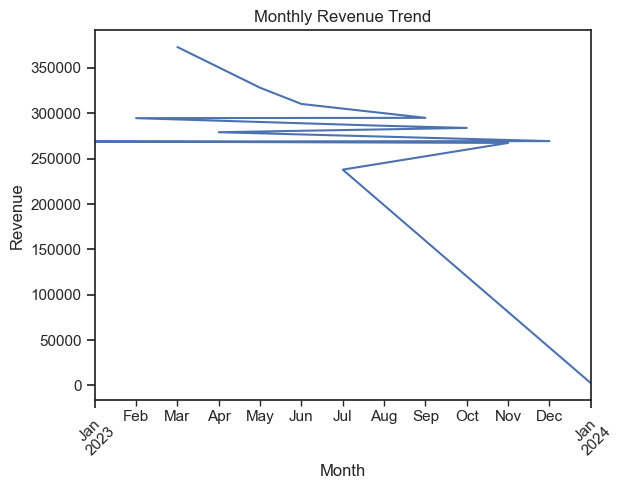

In [14]:
#sns.lineplot(data=monthly_rates.reset_index(), x='month', y='Revenue')  

monthly_rates.plot(kind='line')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()  

In [15]:
monthly_rates.sort_values(ascending=False)

month
2023-03    372868.11
2023-05    328038.22
2023-06    310131.35
2023-09    294844.73
2023-02    294489.37
2023-08    286063.81
2023-10    283715.06
2023-04    278988.41
2023-12    269197.96
2023-01    268704.50
2023-11    267177.93
2023-07    237741.03
2024-01      2481.64
Freq: M, Name: Revenue, dtype: float64

<Axes: ylabel='Product'>

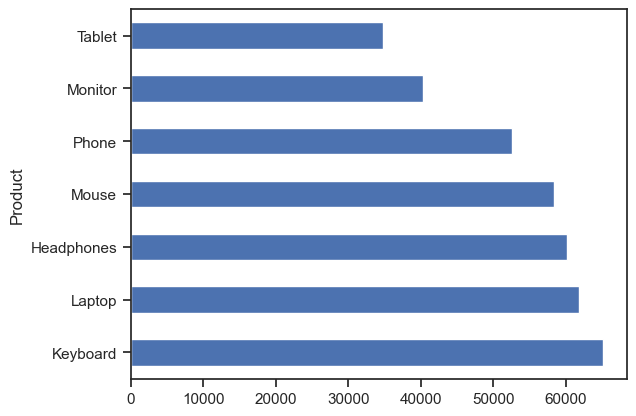

In [16]:
march_data = df[df['month'] == '2023-03']
march_data.groupby('Product')['Revenue'].sum().sort_values(ascending=False).plot(kind='barh')

In [17]:
march_data.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

Region
North    119562.35
East     116987.85
South     84143.74
West      52174.17
Name: Revenue, dtype: float64

In [18]:
march_data.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5)

Product
Keyboard      65088.66
Laptop        61737.83
Headphones    60150.36
Mouse         58302.50
Phone         52515.73
Name: Revenue, dtype: float64

In [19]:
df.groupby('Product')['Profit'].sum().sort_values(ascending=False).head(5)

Product
Keyboard      198305.76
Laptop        185656.17
Headphones    178410.37
Tablet        172234.38
Mouse         164050.29
Name: Profit, dtype: float64

In [20]:
df.groupby("Region")[["Revenue", "Profit"]].sum().sort_values(by="Revenue", ascending=False)


,Revenue,Profit
Region,,
North,1001318.00,344905.82
East,869437.49,309069.28
South,831929.95,288991.80
West,791756.68,275412.40
